# V2 — Classificador Tático (52 Features)

Pipeline completo para a versão V2 do classificador de qualidade de lances de xadrez.
Adiciona 19 features táticas às 33 posicionais da V1: peças indefesas, capturas com ganho, cravadas, rei avançado, tensão.

---

## 1. Setup

In [1]:
import json
import os
import random
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*", category=UserWarning)
plt.rcParams.update({"font.size": 11, "figure.facecolor": "white"})
sns.set_style("whitegrid")

PROJECT_ROOT = Path("..").resolve()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = Path("data")

from version_config import V2
from notebook_utils import *

config = V2

print(f"Versão: {config.label}")
print(f"Diretório de trabalho: {os.getcwd()}")
print("Setup OK")

Versão: V2 — posicional + tática (52 features)
Diretório de trabalho: /Users/noel/Faculdade/ML/Chess
Setup OK


In [2]:
RERUN_PIPELINE = False
print(f"RERUN_PIPELINE = {RERUN_PIPELINE}")
if RERUN_PIPELINE:
    print("⚠️  O pipeline completo será re-executado.")
else:
    print("Usando dados pré-computados.")

RERUN_PIPELINE = False
Usando dados pré-computados.


---

## 2. Dados

Os dados (coleta, filtragem, rotulagem) são os mesmos da V1 — o que muda é a engenharia de features.

In [3]:
df_filtered = pd.read_csv(DATA_DIR / "filtered" / "moves_filtered.csv")
print_dataset_stats(df_filtered)

  DATASET FILTRADO
  Partidas       : 2,911
  Lances (total) : 136,620
  Lances/partida : 46.9
  Colunas        : ['game_id', 'game_site', 'white_elo', 'black_elo', 'time_control', 'result', 'move_number', 'color', 'fen_before', 'move_uci', 'move_san']


In [4]:
df_scored = pd.read_csv(DATA_DIR / "labeled" / "moves_all_scored.csv")
df_labeled = pd.read_csv(DATA_DIR / "labeled" / "moves_labeled.csv")
print_labeling_stats(df_scored, df_labeled)

  ROTULAGEM
  Lances avaliados      : 136,620
  Bom (δ ≥ −50 cp)      : 92,197 (67.5%)
  Descartado (cinzenta) : 27,330 (20.0%)
  Ruim (δ ≤ −150 cp)    : 17,093 (12.5%)
  ──────────────────────
  Dataset final         : 109,290 (bom + ruim)
  Ratio bom:ruim        : 5.39:1


---

## 3. Engenharia de Features — V2 (33 + 19 = 52)

### Novas features táticas (+19)

| Grupo | Qtd. | Features |
|-------|------|----------|
| **Peças indefesas** | 5 | Hanging pieces/value (jogador/adversário), min attacker vs piece |
| **Capturas com ganho** | 4 | Ameaças contra jogador/adversário, valor máximo de ameaça |
| **Cravadas** | 2 | Peças cravadas (jogador/adversário) |
| **Rei avançado** | 4 | Atacantes do rei, colunas abertas, casas de fuga |
| **Tensão** | 4 | Ataques totais, casas disputadas, peças sem defesa |

In [5]:
if RERUN_PIPELINE:
    from extract_features import run as extract_run
    print(f"Extraindo {config.n_features} features V{config.version}...")
    extract_run(num_workers=6, batch_size=1000, v2=True, v3=False)
else:
    print(f"⏭️  Extração de features pulada.")
    print(f"   → {config.features_csv}")

⏭️  Extração de features pulada.
   → data/features/features_v2.csv


In [6]:
df_features = pd.read_csv(config.features_csv)
feature_cols = [c for c in df_features.columns if c != "label"]
print_features_stats(df_features, config)
print(f"\nEstatísticas descritivas:")
df_features[feature_cols].describe().round(2)

  FEATURES — V2
  Fonte       : data/features/features_v2.csv
  Linhas      : 109,290
  Features    : 52
  Valores nulos: 0

Distribuição do label:
label
bom     92197
ruim    17093

Estatísticas descritivas:


,white_pawns,white_knights,white_bishops,white_rooks,white_queens,black_pawns,black_knights,black_bishops,black_rooks,black_queens,...,pinned_pieces_player,pinned_pieces_opponent,king_attackers_player,king_attackers_opponent,king_open_files_player,king_escape_squares_player,total_attacks_player,total_attacks_opponent,contested_squares,undefended_pieces_player
count,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,...,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00
mean,5.99,0.98,1.05,1.67,0.70,6.00,0.97,1.08,1.66,0.70,...,0.11,0.11,0.80,0.71,0.26,2.36,32.71,33.42,13.04,1.25
std,1.44,0.77,0.77,0.59,0.46,1.44,0.78,0.76,0.60,0.46,...,0.32,0.32,0.94,0.90,0.53,1.35,5.90,5.97,4.54,0.93
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,3.00,4.00,0.00,0.00
25%,5.00,0.00,0.00,1.00,0.00,5.00,0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,1.00,30.00,31.00,10.00,1.00
50%,6.00,1.00,1.00,2.00,1.00,6.00,1.00,1.00,2.00,1.00,...,0.00,0.00,1.00,0.00,0.00,2.00,34.00,34.00,13.00,1.00
75%,7.00,2.00,2.00,2.00,1.00,7.00,2.00,2.00,2.00,1.00,...,0.00,0.00,1.00,1.00,0.00,3.00,37.00,37.00,16.00,2.00
max,8.00,2.00,2.00,2.00,2.00,8.00,3.00,2.00,3.00,2.00,...,3.00,3.00,8.00,8.00,3.00,8.00,54.00,53.00,34.00,6.00


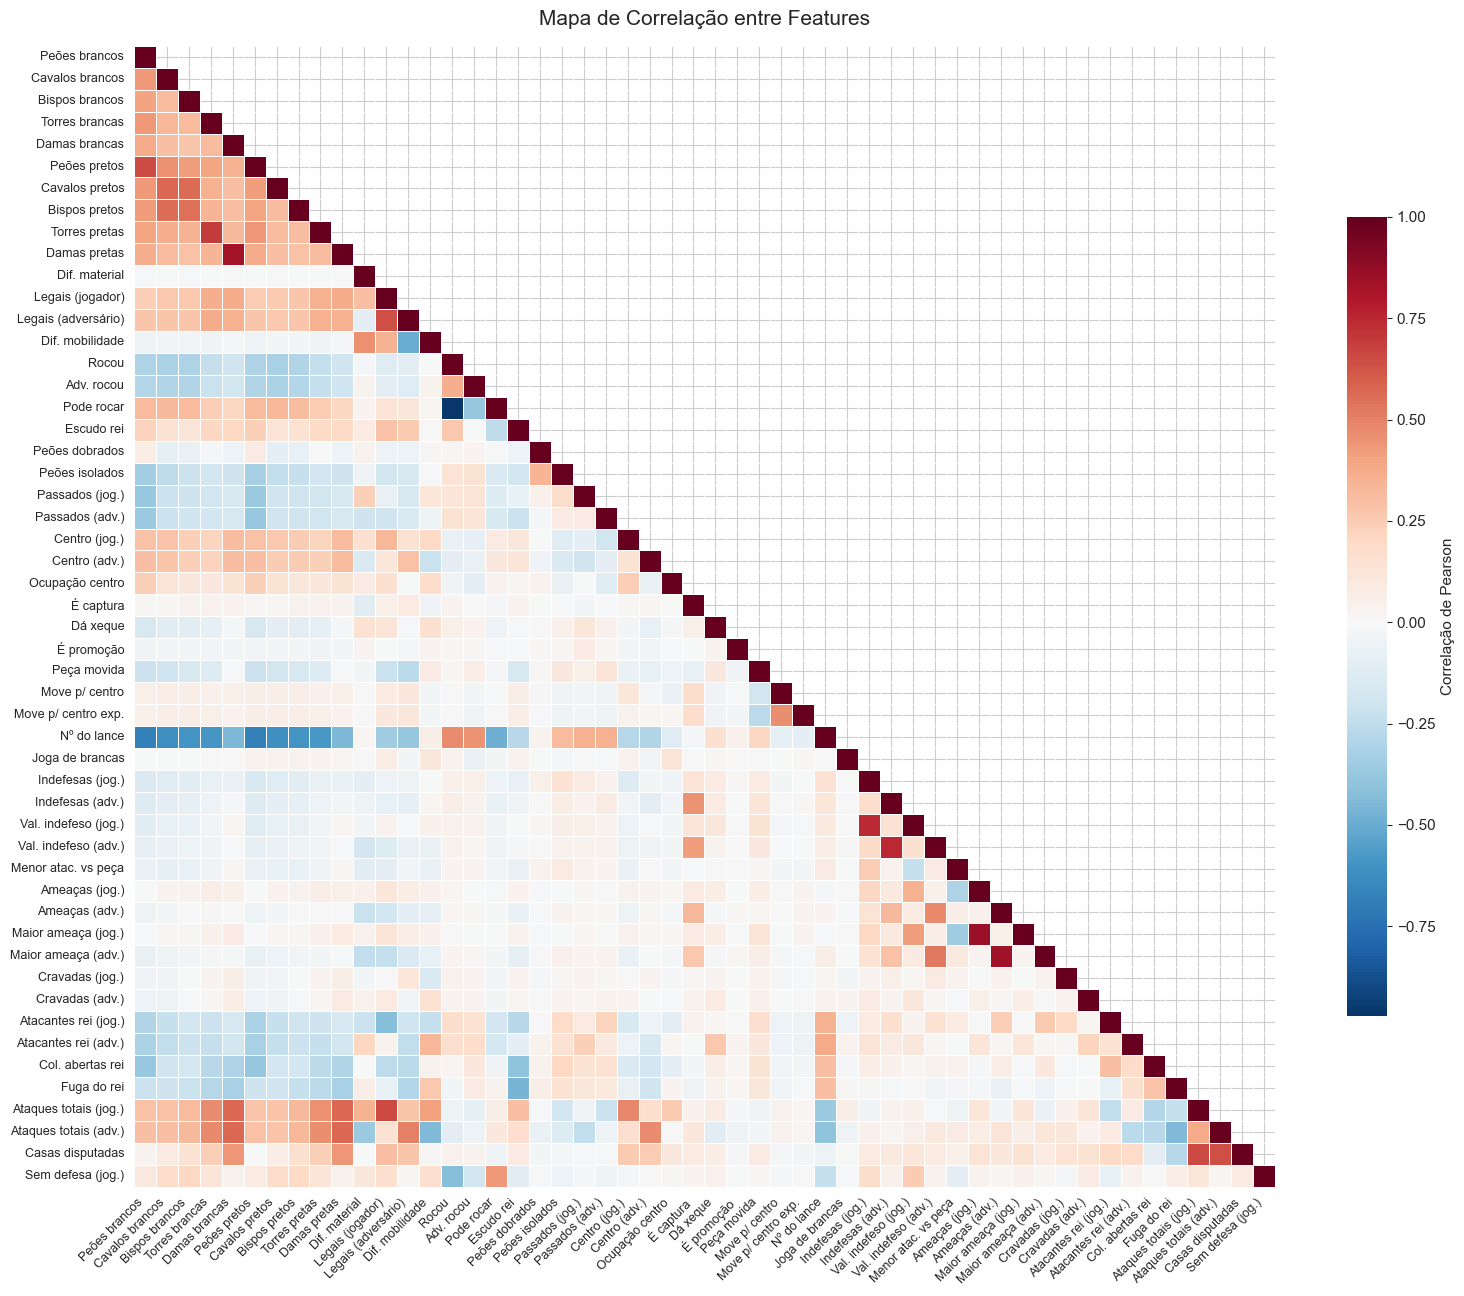

Pares com |correlação| > 0.7:
  Rocou                      ↔  Pode rocar                 r = -0.970
  Ameaças (jog.)             ↔  Maior ameaça (jog.)        r = +0.857
  Ameaças (adv.)             ↔  Maior ameaça (adv.)        r = +0.842
  Damas brancas              ↔  Damas pretas               r = +0.836
  Indefesas (adv.)           ↔  Val. indefeso (adv.)       r = +0.753
  Indefesas (jog.)           ↔  Val. indefeso (jog.)       r = +0.740


In [7]:
plot_correlation_matrix(df_features, feature_cols)

---

## 4. Treino dos Modelos

- Split **70/15/15** com estratificação
- `class_weight="balanced"`
- `GridSearchCV` com 5 folds, métrica F1 da classe "ruim"

In [8]:
X = df_features.drop(columns=["label"])
y = (df_features["label"] == "ruim").astype(int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=RANDOM_SEED
)

print_split_info(X_train, y_train, X_val, y_val, X_test, y_test)

  SPLIT DOS DADOS
  Treino    : 76,546 amostras  (bom=64,574, ruim=11,972, 15.6% ruim)
  Validação : 16,350 amostras  (bom=13,793, ruim=2,557, 15.6% ruim)
  Teste     : 16,394 amostras  (bom=13,830, ruim=2,564, 15.6% ruim)


In [9]:
if RERUN_PIPELINE:
    from train_models import run as train_run
    print(f"Treinando modelos V{config.version}...")
    train_run(v2=config.v2_flag, v3=config.v3_flag)
else:
    print(f"⏭️  Treino pulado (usando modelos pré-treinados de {config.models_dir}).")

dt, rf, feature_names = config.load_models()
print_model_params(dt, rf, config)

⏭️  Treino pulado (usando modelos pré-treinados de data/models_v2).

  DECISION TREE V2 — Melhores hiperparâmetros
  criterion        : gini
  max_depth        : 7
  min_samples_leaf : 1
  class_weight     : balanced

  RANDOM FOREST V2 — Melhores hiperparâmetros
  n_estimators     : 200
  max_depth        : 10
  min_samples_leaf : 5
  class_weight     : balanced


---

## 5. Avaliação

Avaliação no **conjunto de teste** — nunca usado no treino nem no tuning.

In [10]:
print_classification_reports(dt, rf, X_test, y_test)

  DECISION TREE — Classification Report
              precision    recall  f1-score   support

         bom       0.90      0.63      0.74     13830
        ruim       0.24      0.62      0.34      2564

    accuracy                           0.63     16394
   macro avg       0.57      0.62      0.54     16394
weighted avg       0.80      0.63      0.68     16394

  RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

         bom       0.90      0.71      0.80     13830
        ruim       0.27      0.57      0.37      2564

    accuracy                           0.69     16394
   macro avg       0.58      0.64      0.58     16394
weighted avg       0.80      0.69      0.73     16394



In [11]:
df_results = build_results_table(dt, rf, X_test, y_test)
print("Tabela comparativa — Conjunto de teste:\n")
df_results

Tabela comparativa — Conjunto de teste:



,Modelo,Accuracy,F1 (bom),F1 (ruim),Recall (ruim),Precision (ruim),ROC-AUC
0,Decision Tree,0.6302,0.7427,0.3429,0.6170,0.2375,0.6744
1,Random Forest,0.6912,0.7958,0.3664,0.5710,0.2698,0.7079


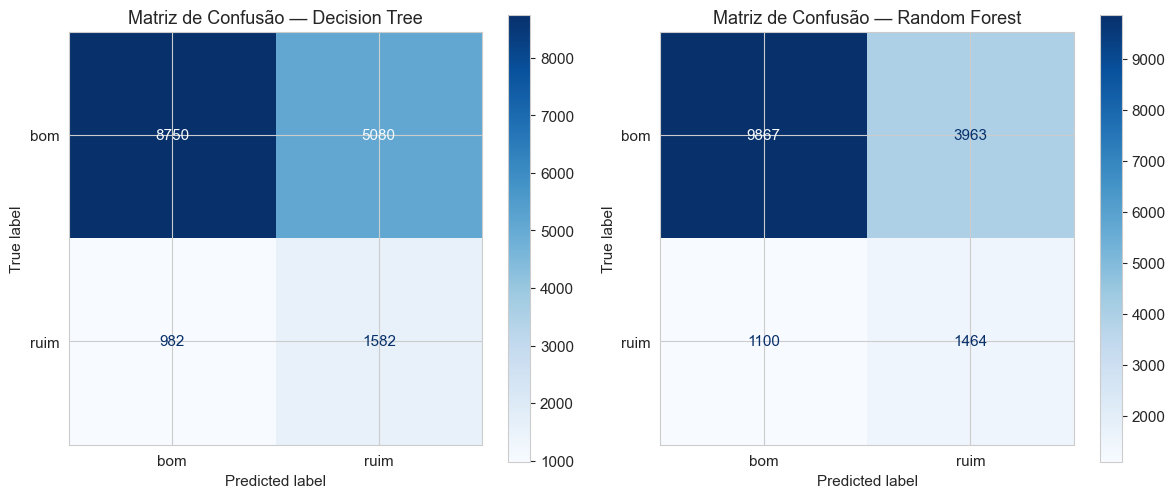

In [12]:
plot_confusion_matrices(dt, rf, X_test, y_test)

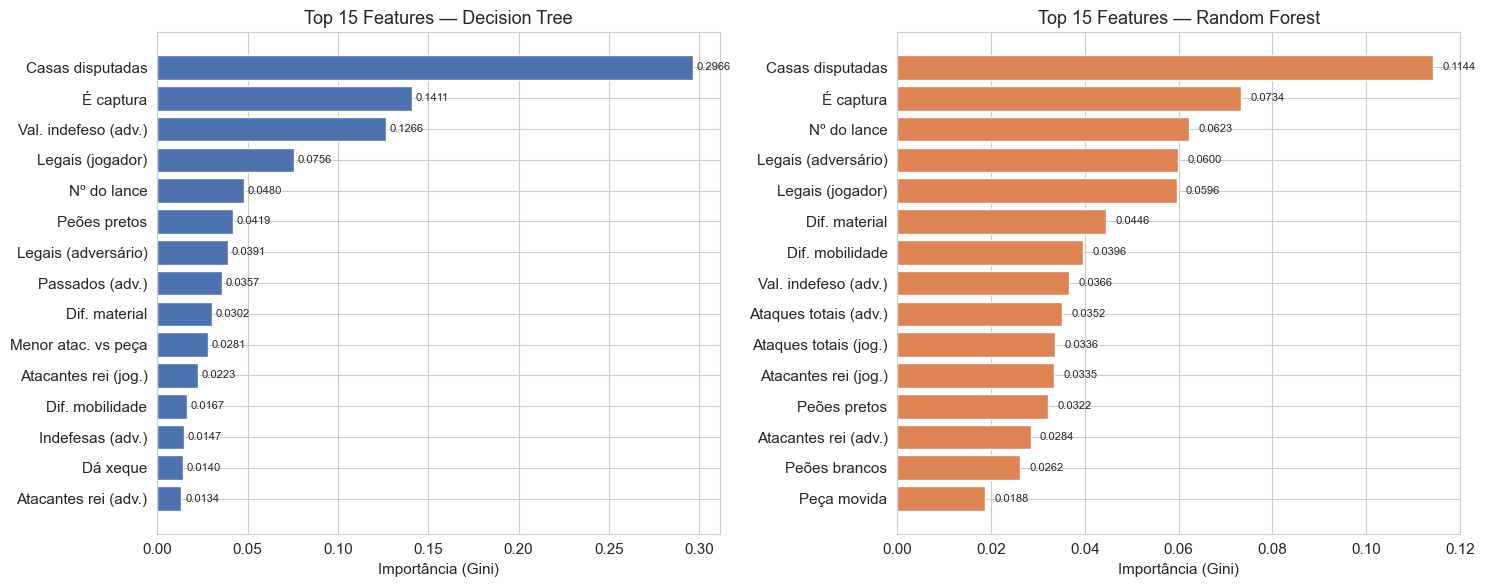

In [13]:
plot_feature_importances_side_by_side(dt, rf, feature_names)

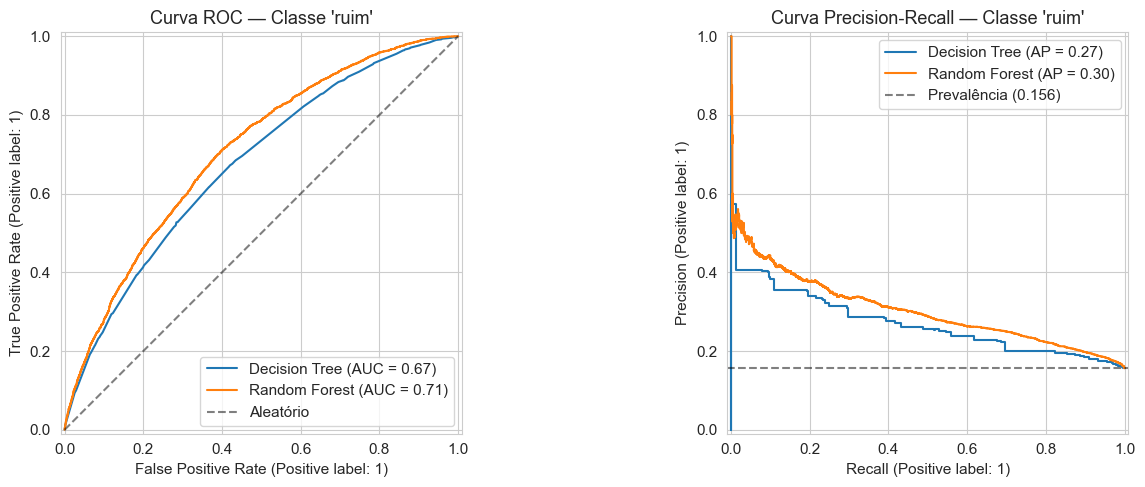

In [14]:
plot_roc_pr_curves(dt, rf, X_test, y_test)

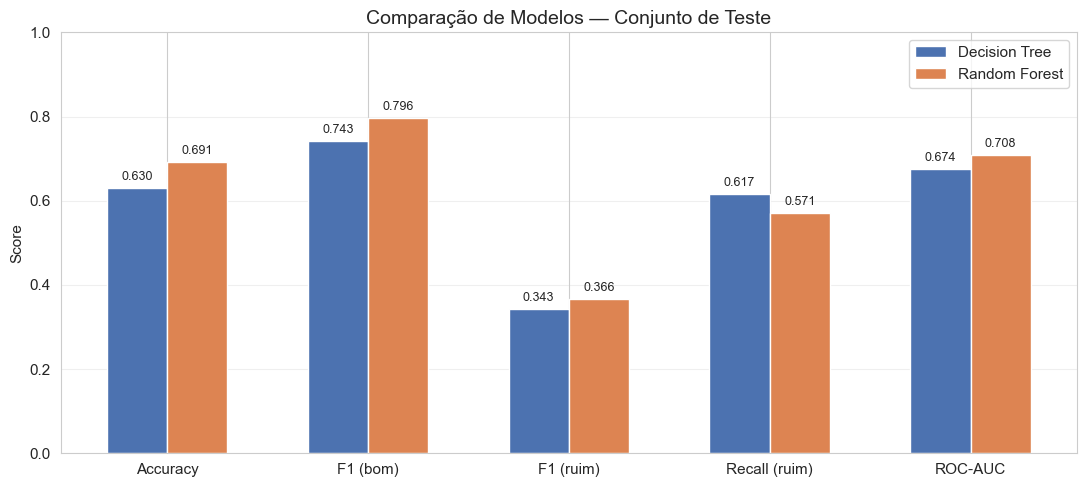

In [15]:
plot_metrics_comparison(dt, rf, X_test, y_test)

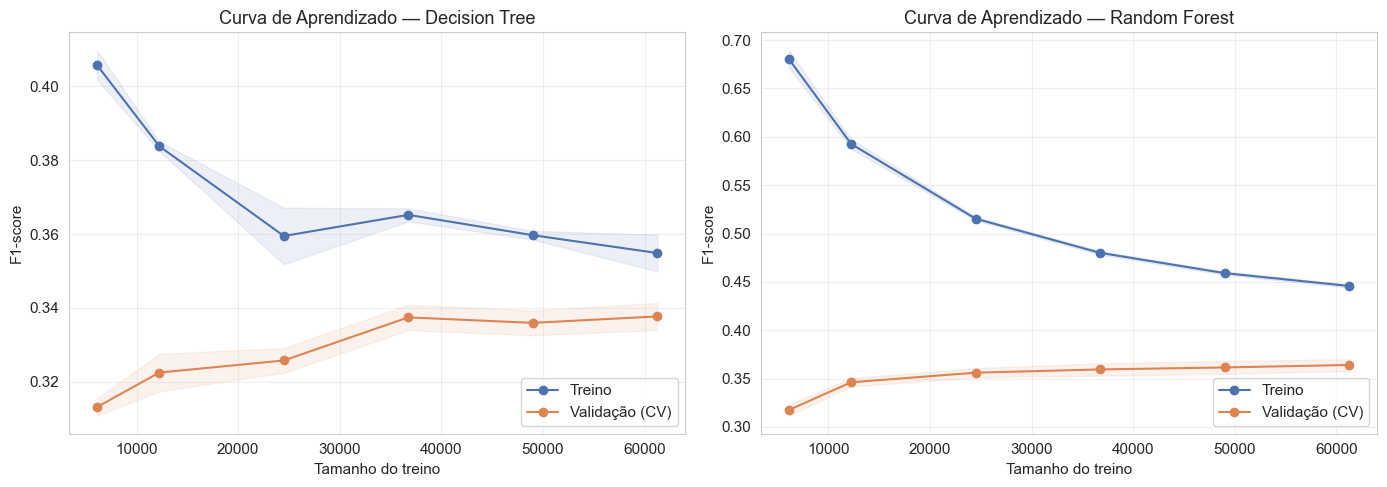

In [16]:
plot_learning_curves(dt, rf, X_train, y_train)

### Importância das 19 Features Táticas

Qual o impacto específico das novas features táticas no modelo?

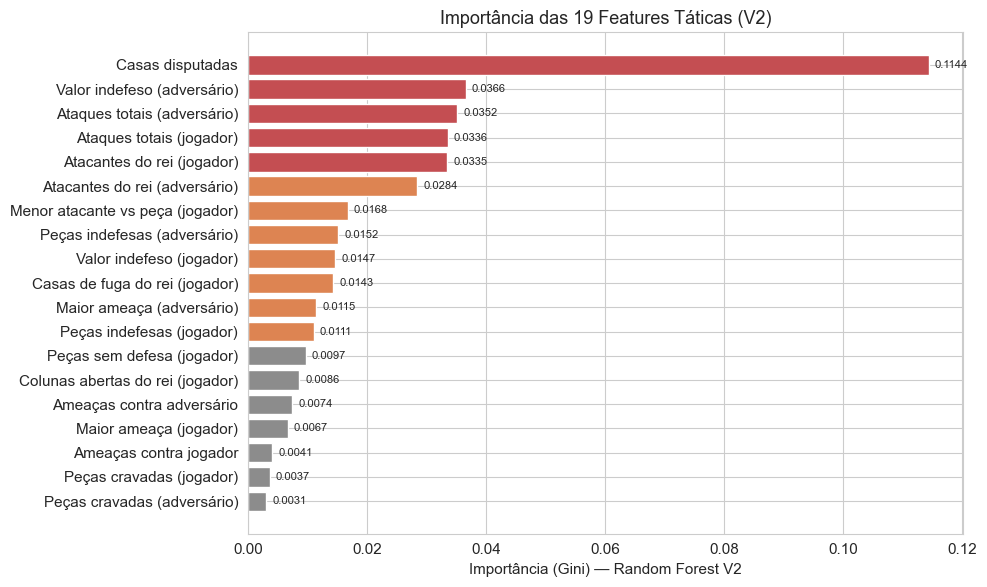

Feature tática #1: Casas disputadas (importância = 0.1144)


In [17]:
plot_tactical_features_importance(config)

---

## 6. Diagnóstico V2: Por que +1.4pp não basta?

A V2 adicionou features que detectam **perigos no tabuleiro** (peças indefesas, cravadas, tensão). A melhoria foi consistente mas modesta.

> **Dois lances diferentes na mesma posição teriam exatamente as mesmas 52 features.**

As features V1+V2 capturam o **cenário antes do lance**, mas não dizem se o lance **lida com os perigos ou os ignora**.

| Versão | O que sabe | O que falta |
|--------|-----------|-------------|
| V1 | "A posição tem material desigual, baixa mobilidade" | Não sabe que há ameaças |
| V2 | "Há 2 peças indefesas e 1 cravada" | Não sabe se o lance resolve ou ignora isso |
| **V3** | **"O lance deixou 1 peça indefesa e permite captura grátis"** | — |

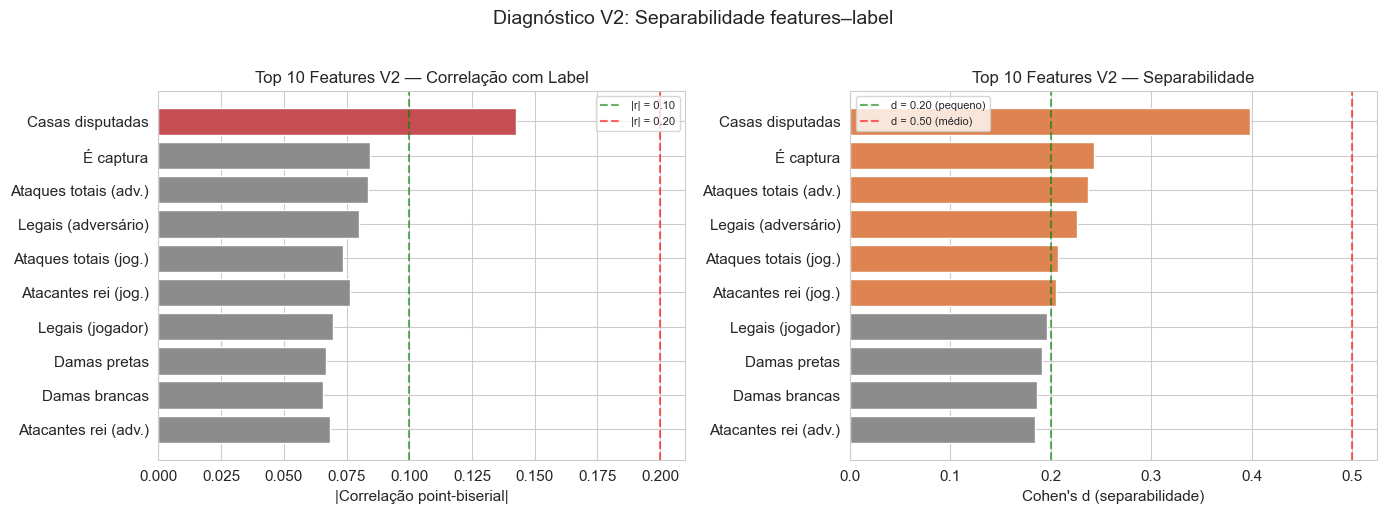

Melhor feature: contested_squares → |r| = 0.143, Cohen's d = 0.398
Features com |r| ≥ 0.10: 1


In [18]:
plot_diagnostic(df_features, feature_cols, "V2")

---

## 7. Interpretação

### Regras da Árvore de Decisão

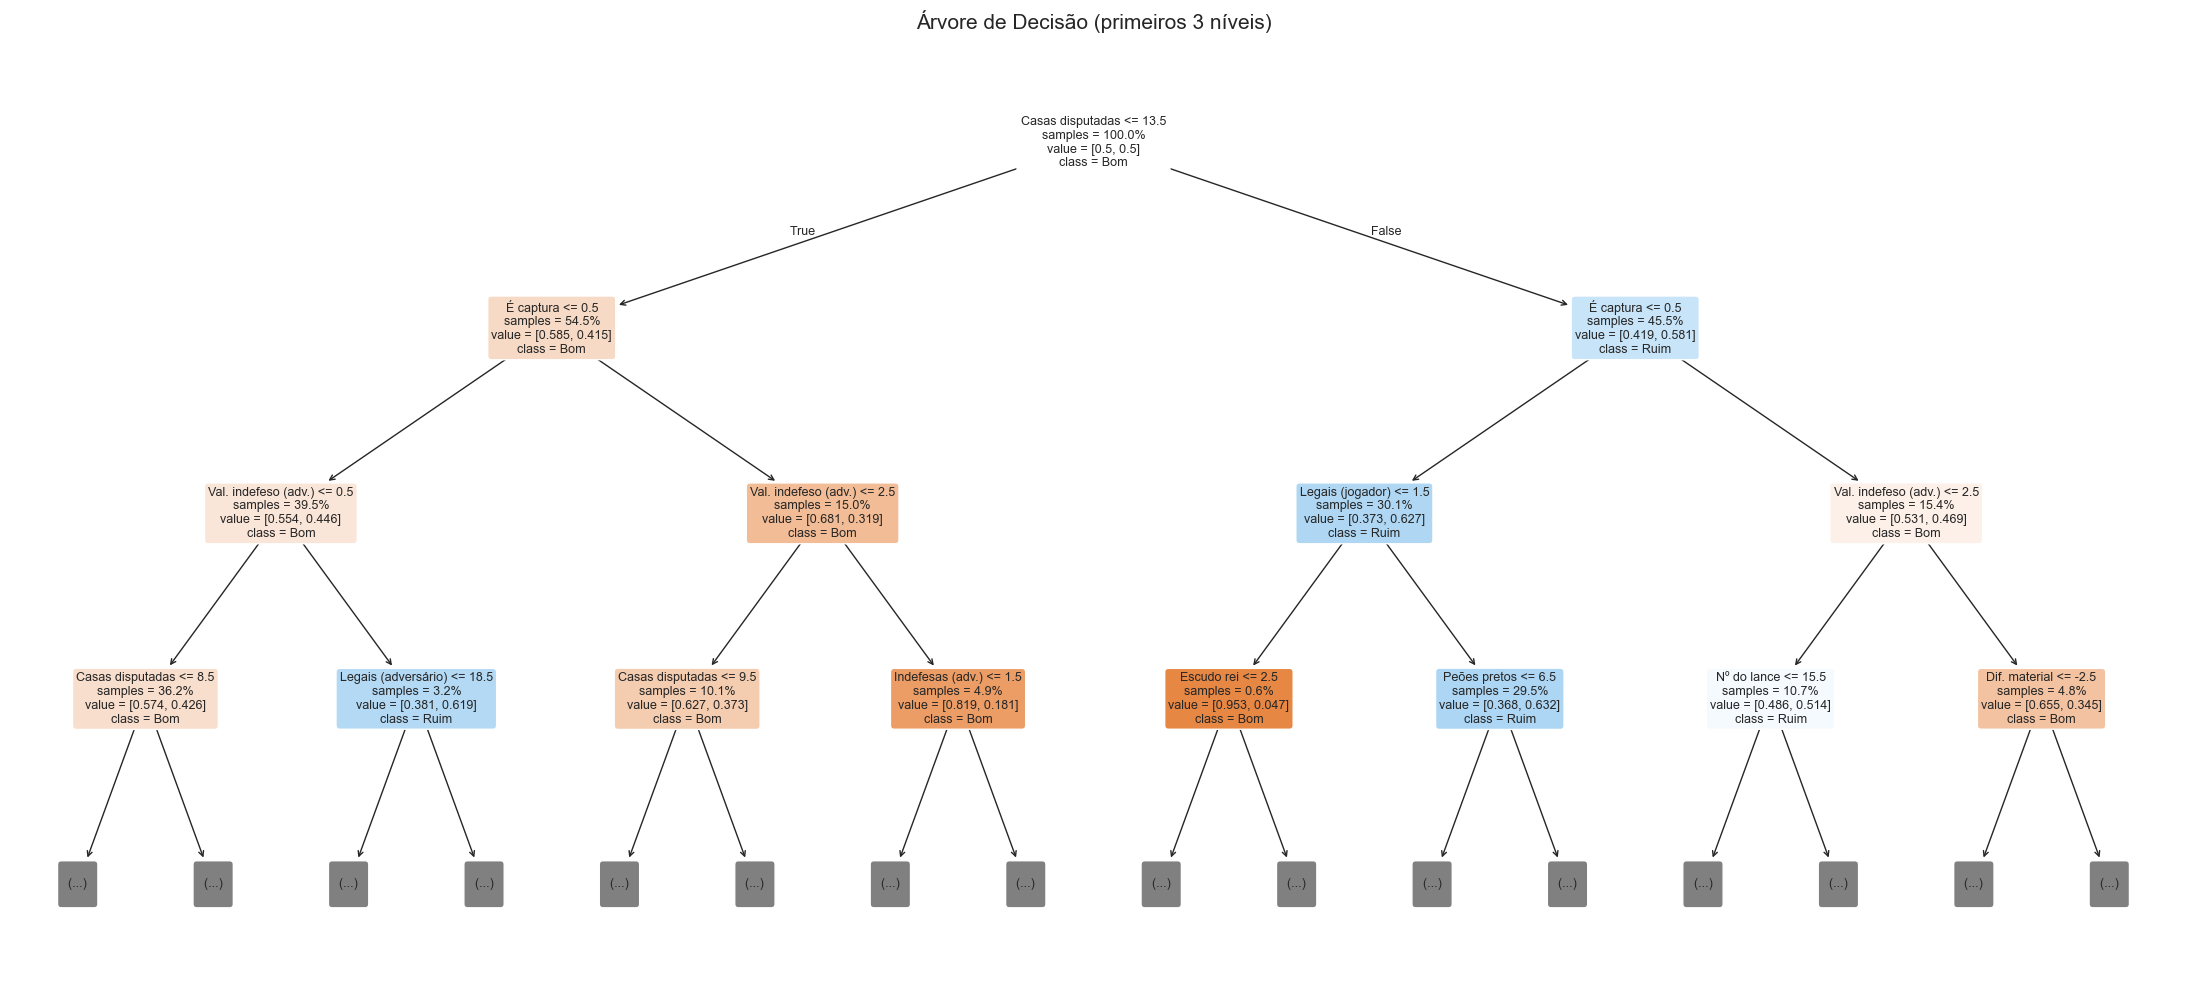

In [19]:
plot_decision_tree(dt, feature_names)

In [20]:
print_tree_rules(config)

═══════════════════════════════════════════════════════════
Regras da Árvore de Decisão V2 — Traduzidas para xadrez
═══════════════════════════════════════════════════════════

Legenda:
  - "Casas disputadas": nº de casas atacadas por ambos os lados
  - "Valor indefeso (adversário)": valor material de peças hanging
  - "Peças cravadas": peças que não podem mover sem expor peça mais valiosa
  - "Atacantes do rei": nº de peças inimigas atacando zona do rei
  - Demais features: ver legenda V1

═══════════════════════════════════════════════════════════

|--- Casas disputadas <= 13.50
|   |--- É captura <= 0.50
|   |   |--- Valor indefeso (adversário) <= 0.50
|   |   |   |--- Casas disputadas <= 8.50
|   |   |   |   |--- Peões passados (adversário) <= 0.50
|   |   |   |   |   |--- Peças indefesas (jogador) <= 0.50
|   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |--- Peças indefesas (jogador) >  0.50
|   |   |   |   |   |   |--- truncated branch of depth 2
|   |

### Análise de Erros

In [21]:
show_error_examples(config)


  FALSOS POSITIVOS — Decision Tree V2
  (modelo disse "ruim", lance é bom)

  FP-1: dxe5 (lance #20, white)
    Delta: -3 cp | Partida: https://lichess.org/iLmchWee
    Features: Casas disputadas=19; É captura=1; Val. indefeso (adv.)=0; Legais (jogador)=40; Nº do lance=20

  FP-2: f3 (lance #22, white)
    Delta: -5 cp | Partida: https://lichess.org/PnlqBHYj
    Features: Casas disputadas=20; É captura=0; Val. indefeso (adv.)=0; Legais (jogador)=38; Nº do lance=22

  FP-3: Bg7 (lance #17, black)
    Delta: 19 cp | Partida: https://lichess.org/BKQXch6A
    Features: Casas disputadas=15; É captura=0; Val. indefeso (adv.)=1; Legais (jogador)=44; Nº do lance=17

  FP-4: Qg4 (lance #19, white)
    Delta: -38 cp | Partida: https://lichess.org/bRkKD0xN
    Features: Casas disputadas=17; É captura=0; Val. indefeso (adv.)=0; Legais (jogador)=48; Nº do lance=19

  FP-5: Kf8 (lance #36, black)
    Delta: -18 cp | Partida: https://lichess.org/as8EWF69
    Features: Casas disputadas=11; É captura=

---

## 8. Conclusões V2

- **RF F1-ruim = 0.37** (+1.4 pp vs V1), **AUC = 0.71** (+2.4 pp) — melhoria consistente mas modesta.
- `contested_squares` (casas disputadas) é a feature #1 do RF V2, superando todas as 33 features V1.
- **Diagnóstico:** features pré-lance não distinguem lances diferentes na mesma posição — falta avaliar o impacto do lance.
- **Próximo passo (V3):** adicionar features de look-ahead — deltas antes/depois, resposta do adversário, SEE.